In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
# read the necessary data
rawdata = pd.read_csv('./data/clean/clean_data.csv')
# convert the date column to datetime format
# format="mixed" parses each value independently (the column mixes dd/mm/yyyy and
# dd/mm/yy, e.g. some days in Oct-Dec 2024 use a 2-digit year); inferring a single
# format for the whole column would silently coerce mismatched rows to NaT and drop
# them in the groupby below.
rawdata["DATE"] = pd.to_datetime(rawdata["DATE"], format="mixed", dayfirst=True, errors='coerce')
# turn all column into numeric, except the date  and heure columns
for col in rawdata.columns:
    if col not in ['DATE', 'HEURE']:
        rawdata[col] = pd.to_numeric(rawdata[col], errors='coerce')

# replace Heure values by categories
# 8h00 is the morning, 10h30 or 10h00 is midday, 14h00 or 15h30 is the afternoon.
def categorize_heure(heure):
    if pd.isna(heure):
        return np.nan
    else:
        heure = str(heure).strip()  # Remove any leading/trailing whitespace
        if heure in ['8h00', '8h30']:
            return 'morning'
        elif heure in ['10h00', '10h30']:
            return 'midday'
        elif heure in ['14h00', '15h00', '15h30']:
            return 'afternoon'
        else:
            return 'unknown'
rawdata['HEURE'] = rawdata['HEURE'].apply(categorize_heure)

# avergae the values of the same day
avgdata = rawdata.drop(columns=['HEURE']).groupby('DATE').mean().reset_index()

## Catch Basin

In [3]:
# select column that have BC in their name
BC_data = avgdata[['DATE'] + [col for col in avgdata.columns if 'BC' in col]]
BC_data.head()

,DATE,pH_BC,Température_BC,Conductivité_BC,TDS_BC,Turbidité_BC
0,2024-01-01,8.260000,16.833333,55.033333,33.02,0.403333
1,2024-01-02,8.246667,16.300000,55.000000,33.00,0.973333
2,2024-01-03,8.226667,17.066667,54.700000,32.82,0.930000
3,2024-01-04,8.206667,16.933333,54.933333,32.96,0.326667
4,2024-01-05,NaN,NaN,NaN,NaN,NaN


#### Descriptive Statistics

In [4]:
BC_data.describe()

,DATE,pH_BC,Température_BC,Conductivité_BC,TDS_BC,Turbidité_BC
count,382,346.000000,345.000000,343.000000,338.000000,342.000000
mean,2024-07-17 14:34:33.298429,8.086452,20.861391,54.224742,36.219514,0.694106
min,2024-01-01 00:00:00,7.900000,15.166667,52.900000,32.500000,0.000000
25%,2024-04-07 06:00:00,8.030000,17.500000,53.600000,33.060000,0.166250
50%,2024-07-17 12:00:00,8.080000,20.600000,54.100000,37.310000,0.347500
75%,2024-10-26 18:00:00,8.130000,24.100000,54.683333,37.730000,0.682500
max,2025-01-31 00:00:00,8.310000,29.000000,56.333333,39.433333,12.000000
std,NaN,0.072836,3.470976,0.807008,2.272854,1.350203


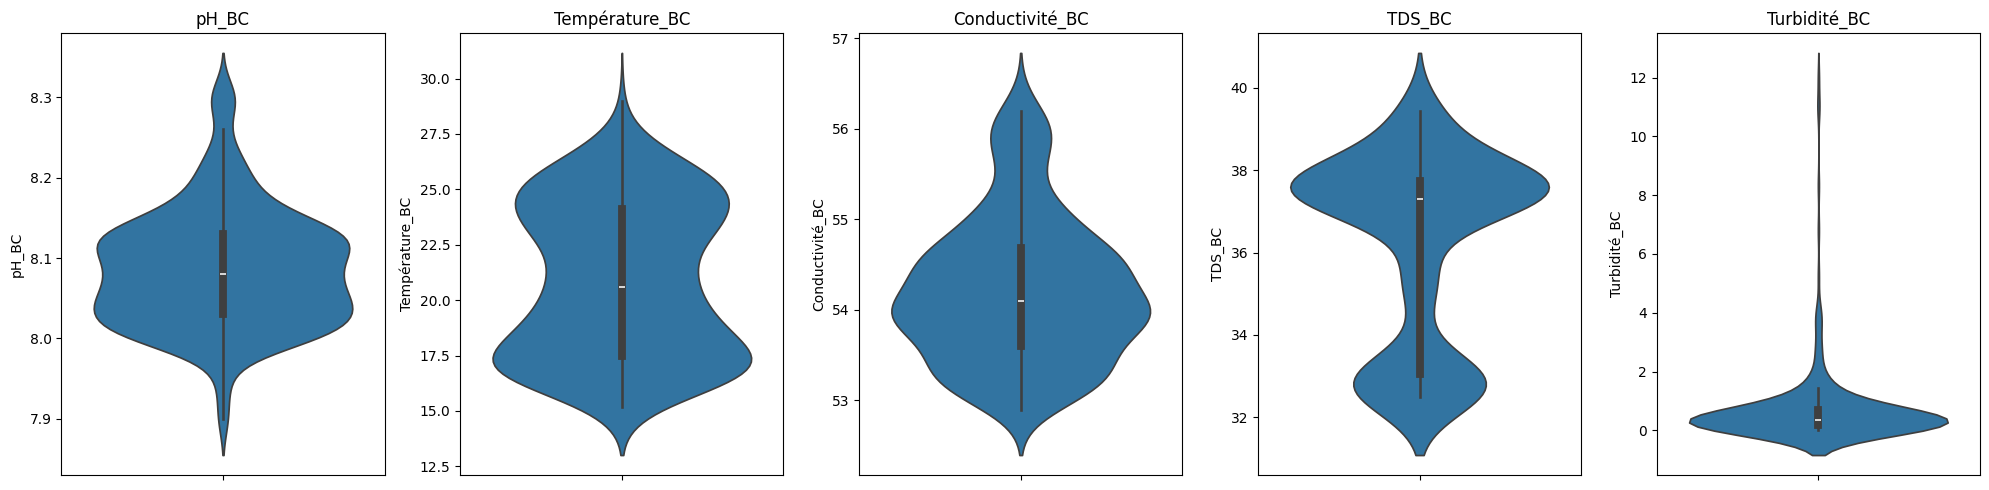

In [5]:
# boxplot of BC data
fig, axes = plt.subplots(1, len(BC_data.columns) - 1, figsize=(20, 5))
for ax, col in zip(axes, BC_data.columns[1:]):
    sns.violinplot(y=BC_data[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

#### Temporal Evolution of the data

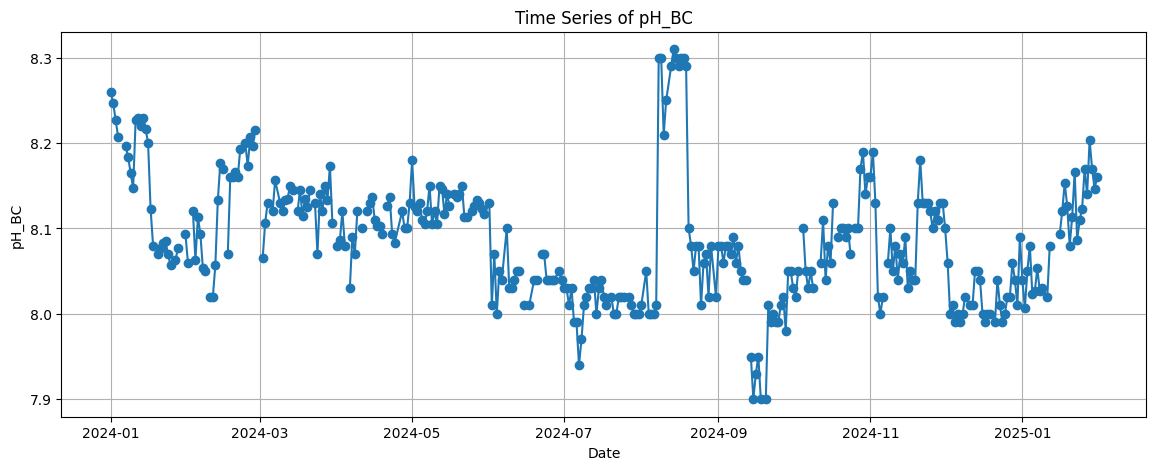

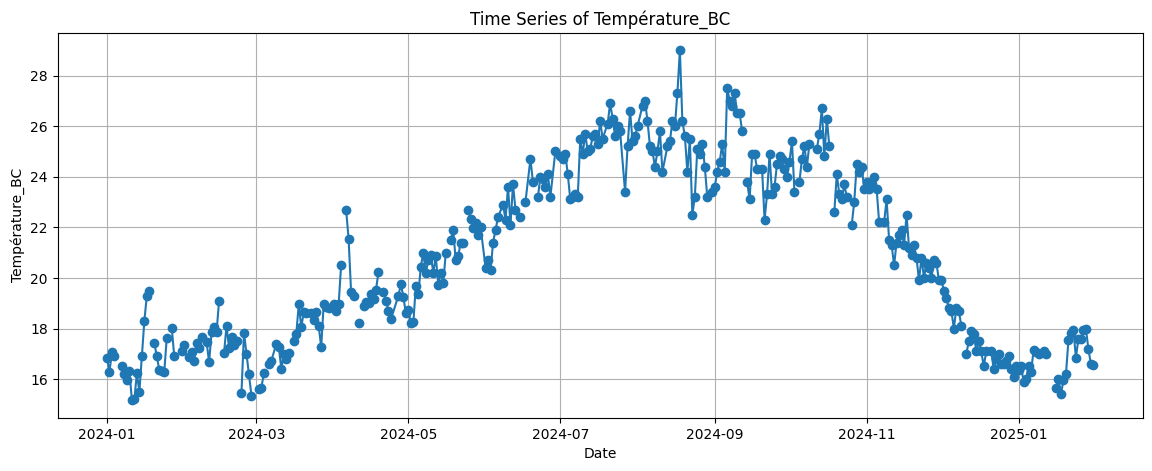

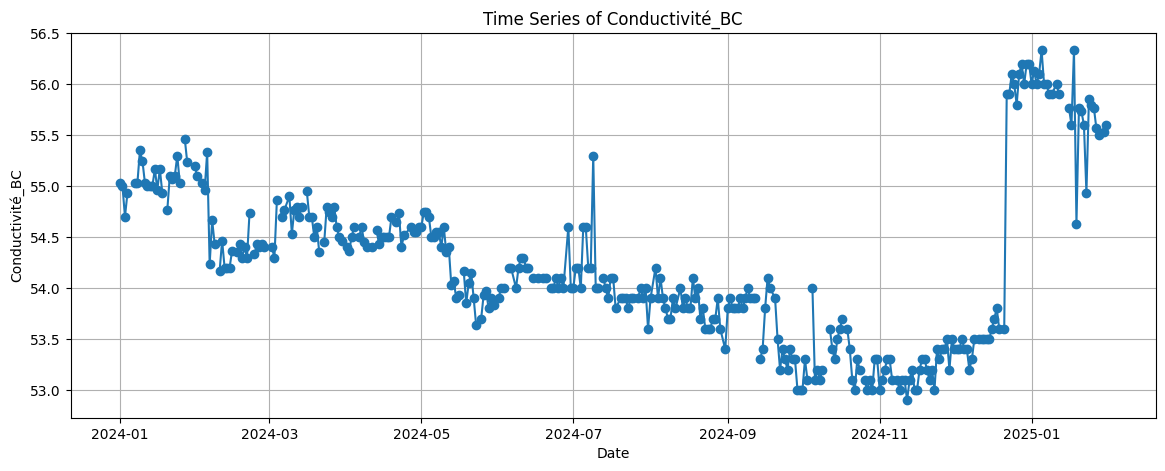

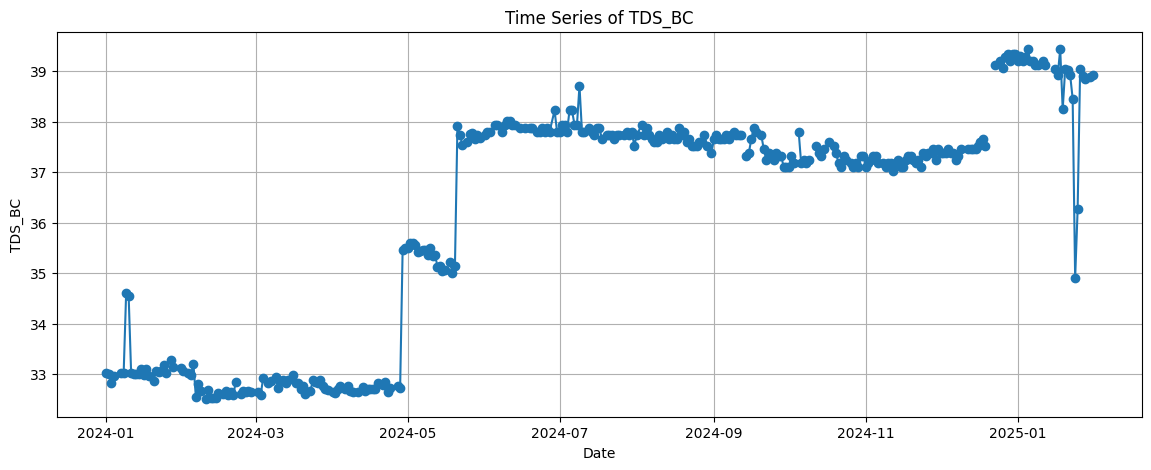

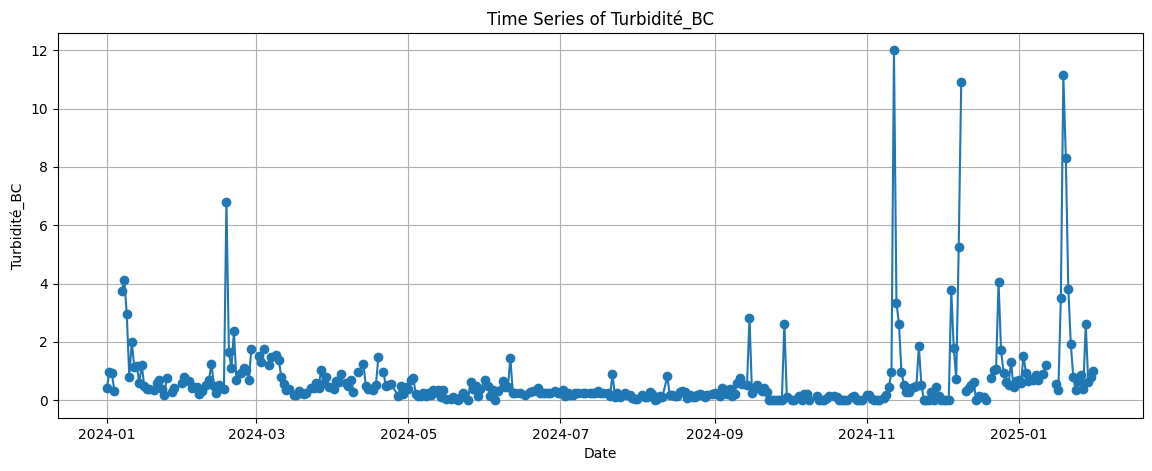

In [6]:
for col in BC_data.columns:
    if col != 'DATE':
        plt.figure(figsize=(14, 5))
        plt.plot(BC_data['DATE'], BC_data[col], marker='o')
        plt.title(f'Time Series of {col}')
        plt.xlabel('Date')
        plt.ylabel(col)
        plt.grid()
        plt.show()

#### Visualtion of the relationship between variables

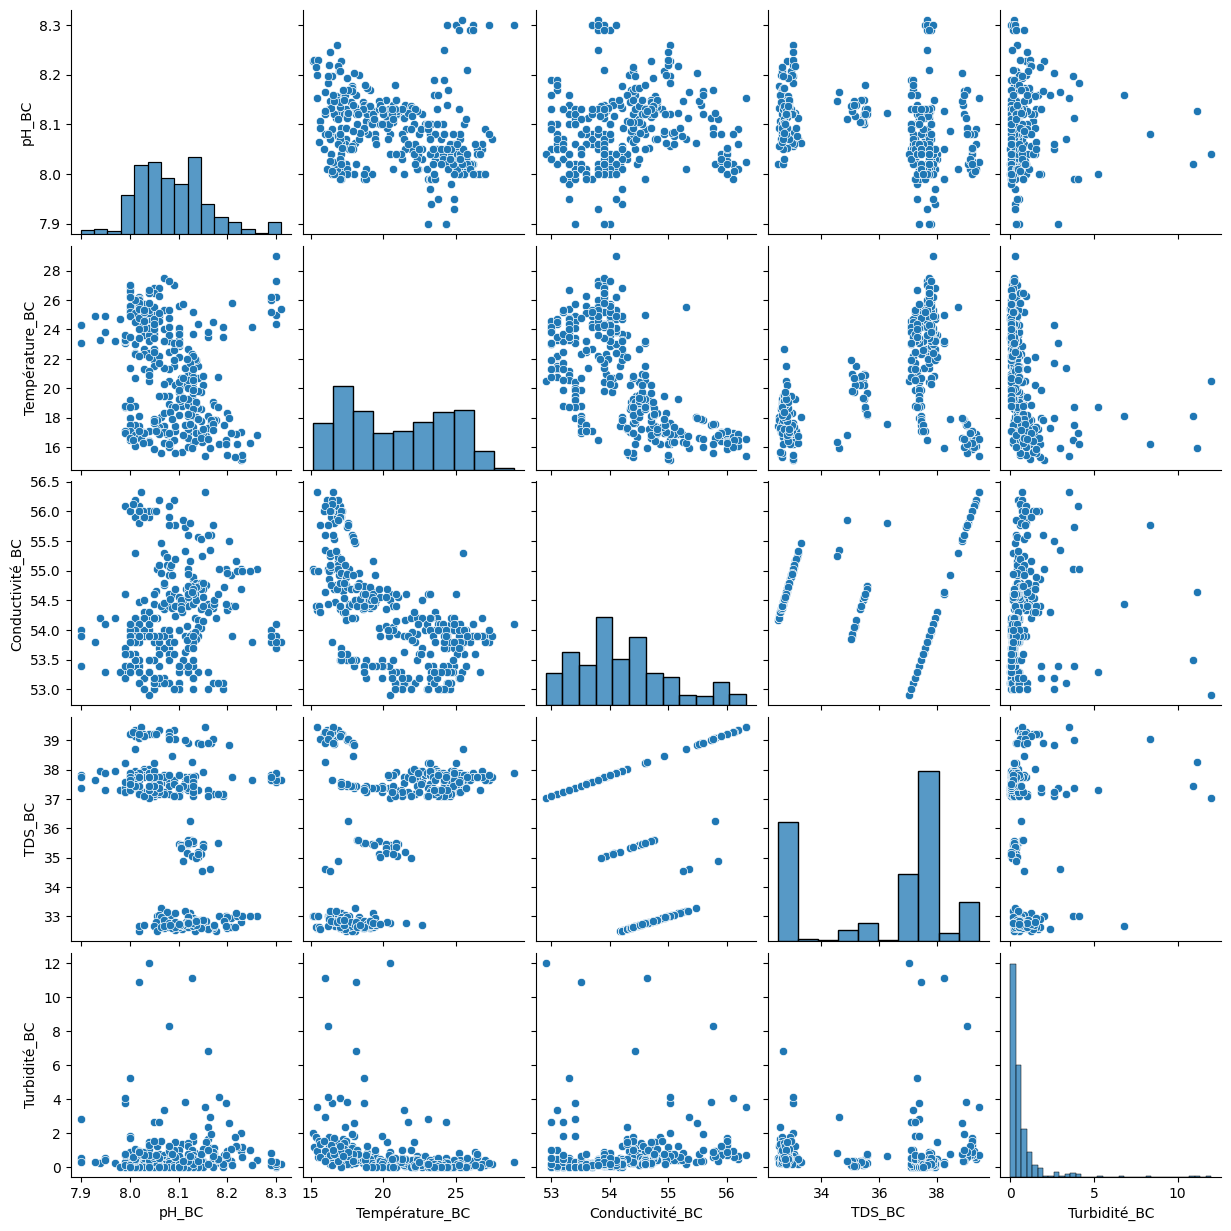

In [7]:
sns.pairplot(BC_data.iloc[:, 1:])

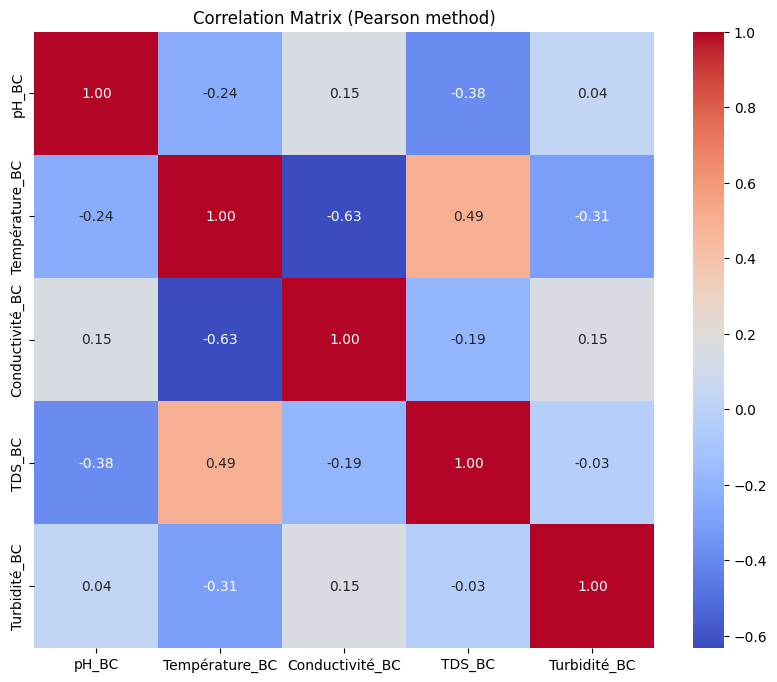

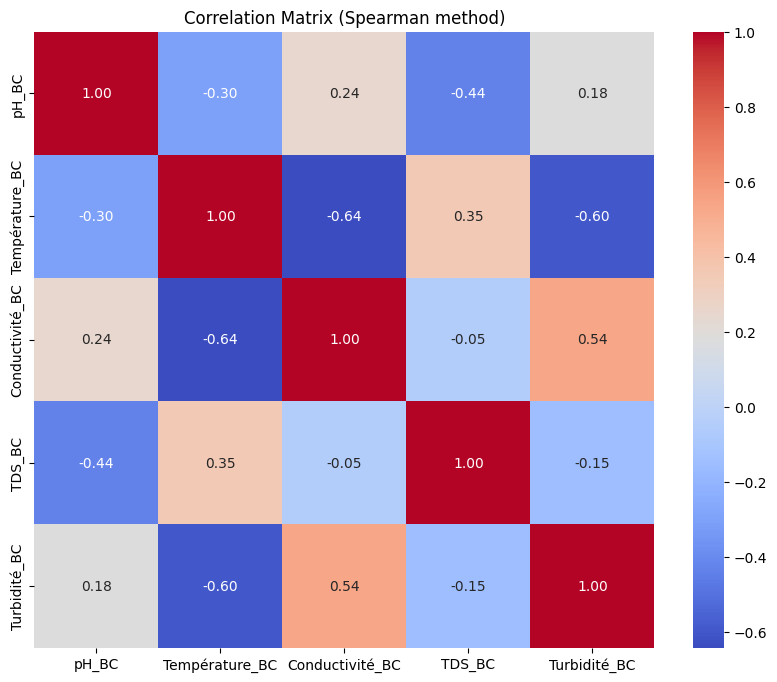

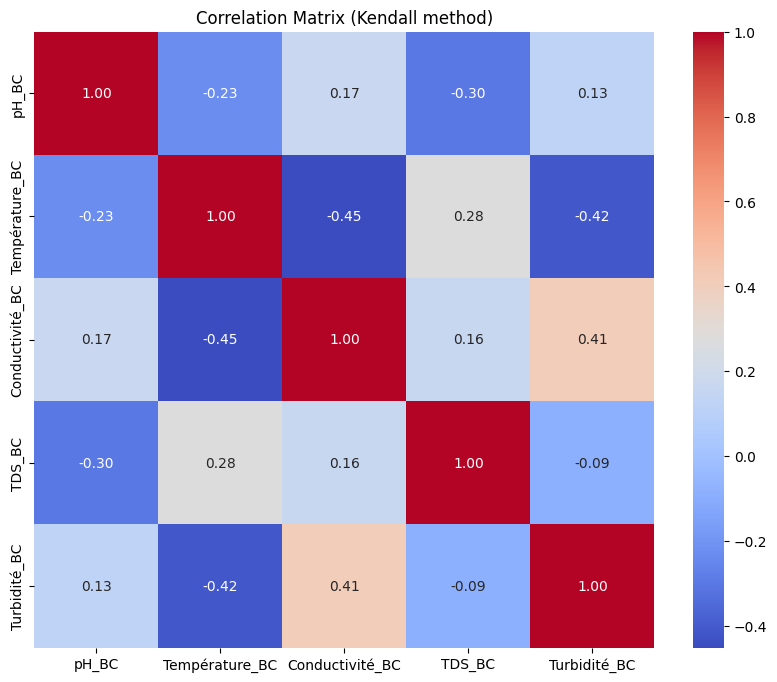

In [8]:
# calculate the correlation matrix using Pearson correlation, spearman correlation, and Kendall correlation
correlation_methods = ['pearson', 'spearman', 'kendall']
for method in correlation_methods:
    corr_matrix = BC_data.iloc[:, 1:].corr(method=method)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(f'Correlation Matrix ({method.capitalize()} method)')
    plt.show()

#### Time series features analysis

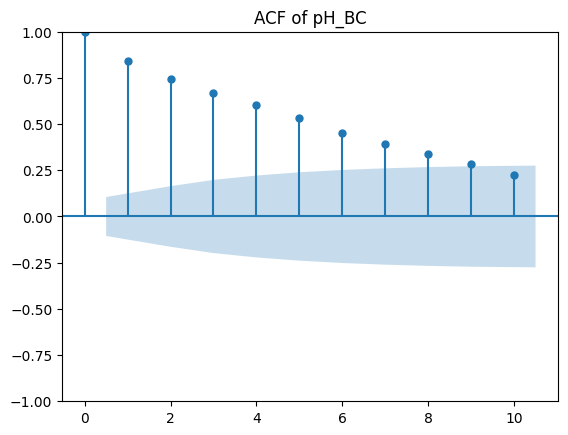

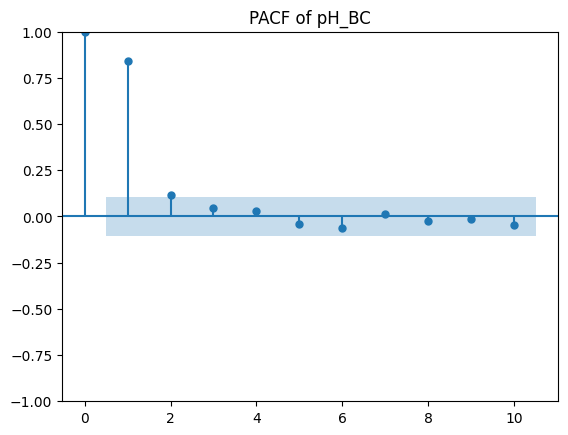

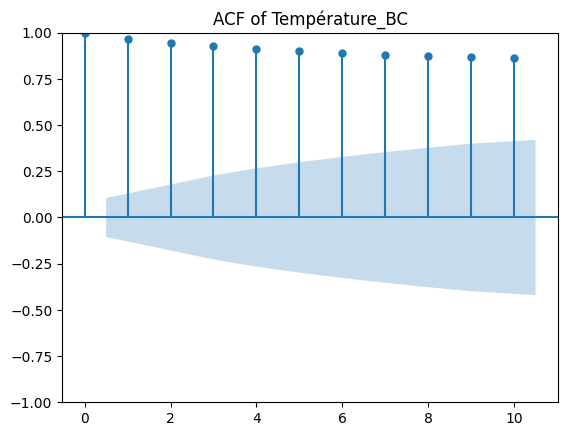

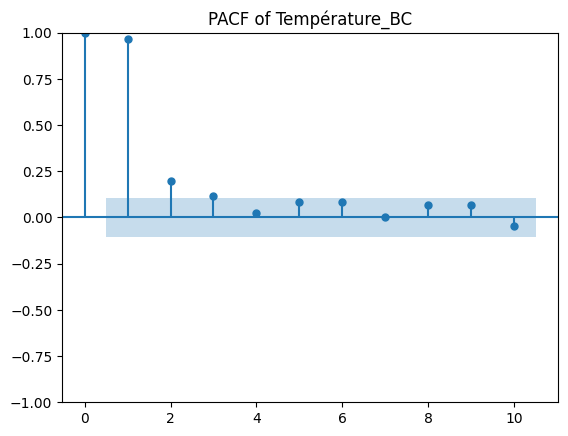

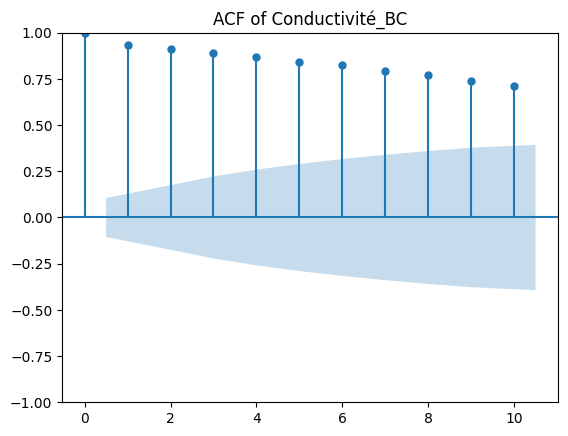

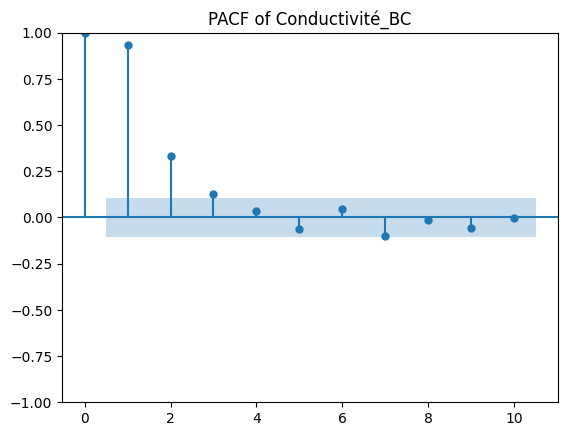

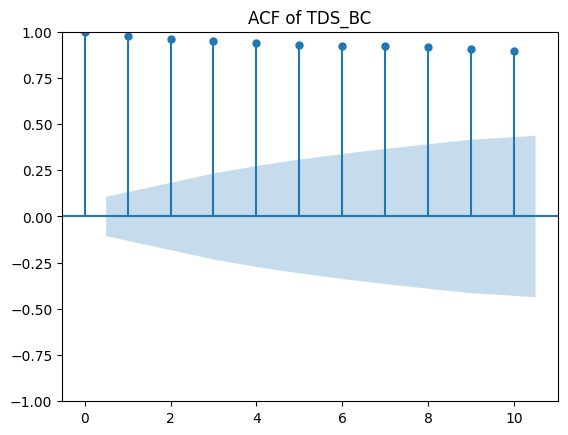

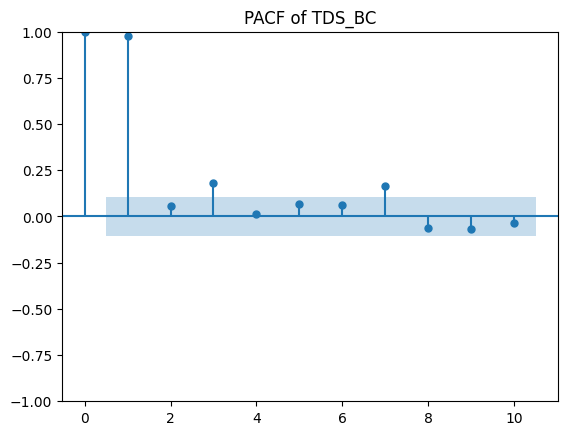

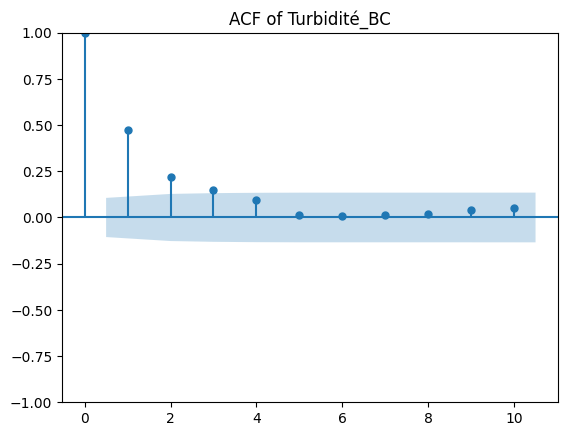

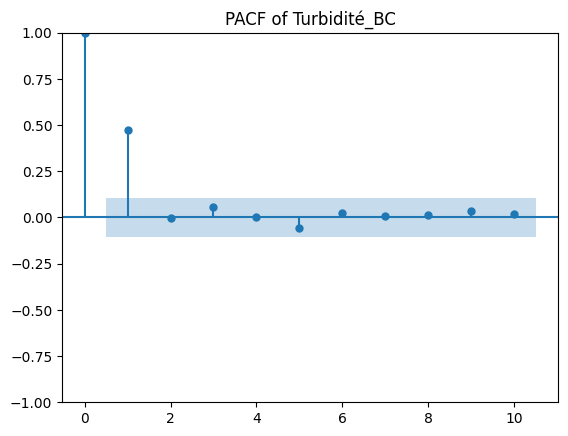

In [9]:
# ACF and PACF for each BC variable
for col in BC_data.columns[1:]:
    plot_acf(BC_data[col].dropna(), lags=10)
    plt.title(f'ACF of {col}')
    plt.show()

    plot_pacf(BC_data[col].dropna(), lags=10)
    plt.title(f'PACF of {col}')
    plt.show()

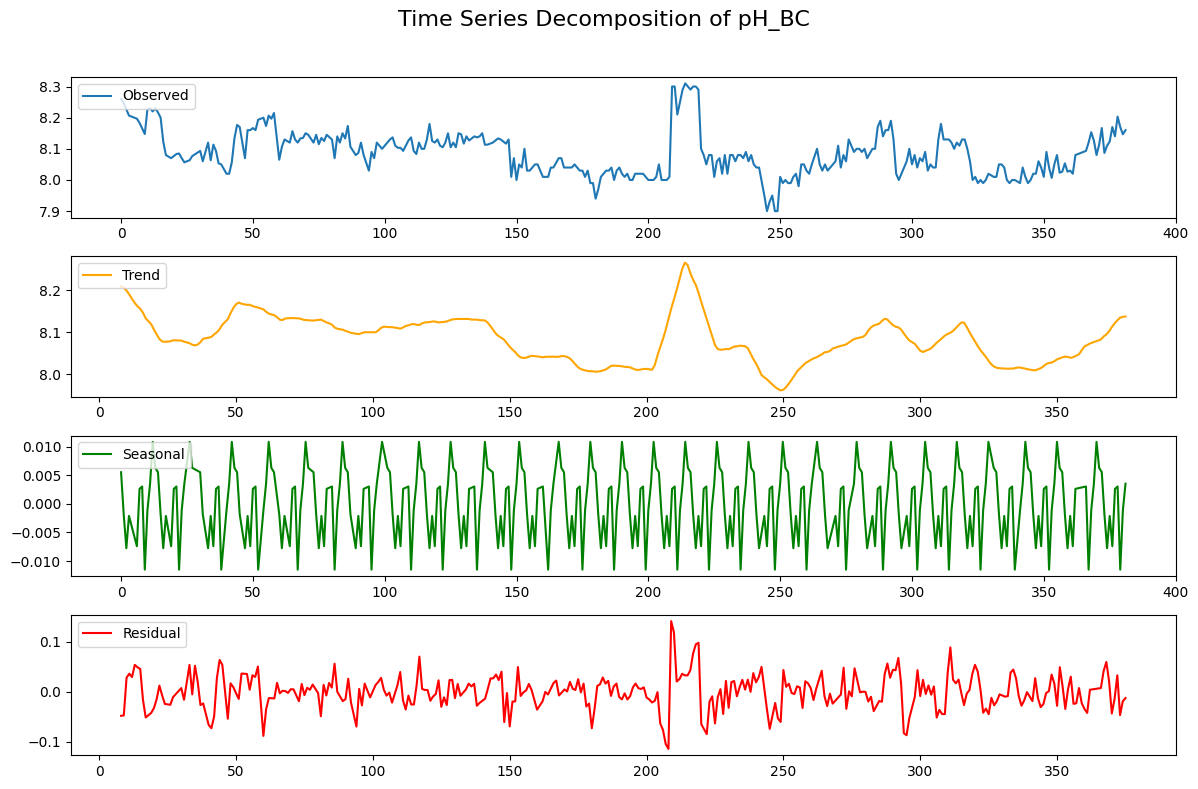

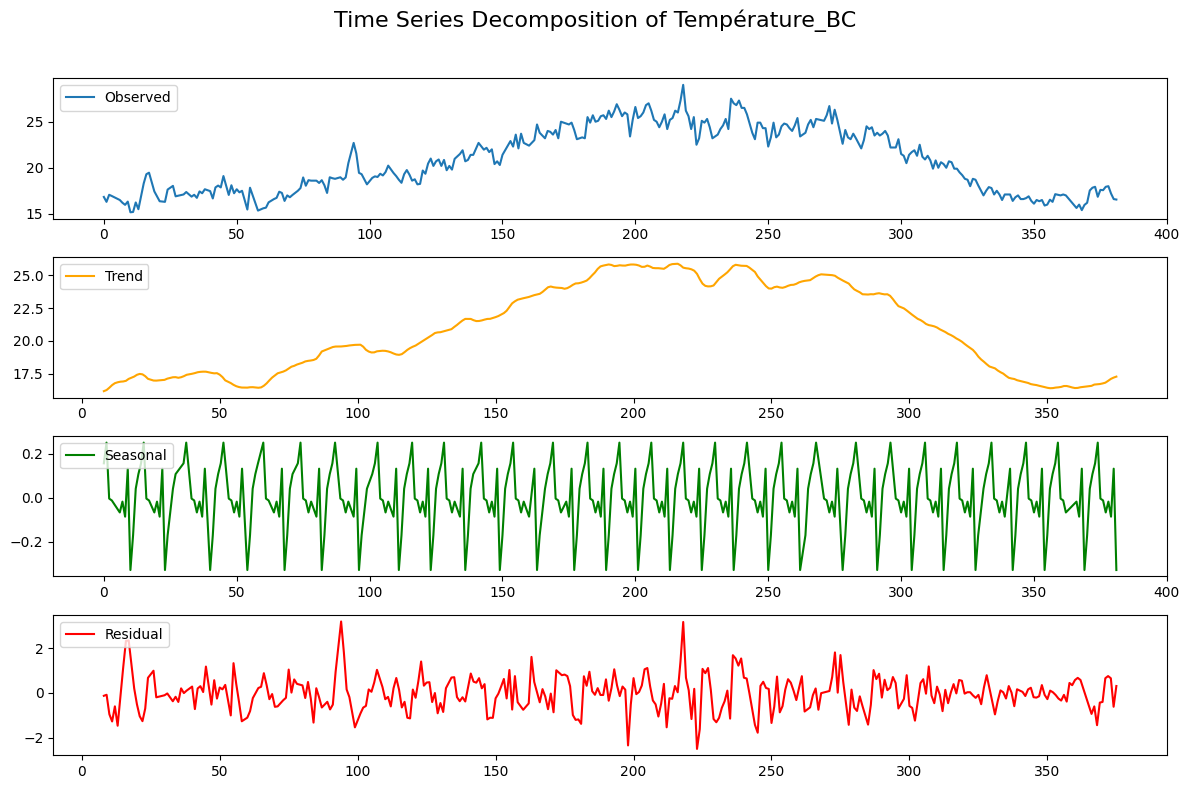

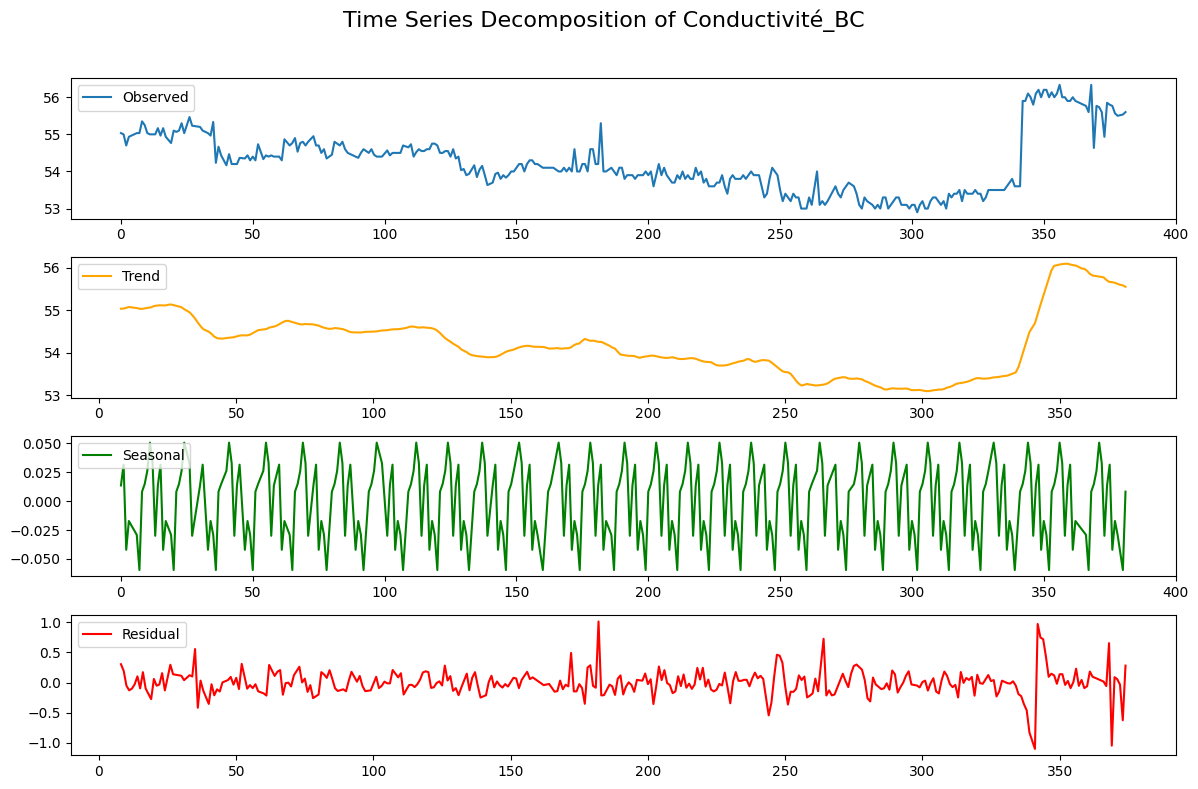

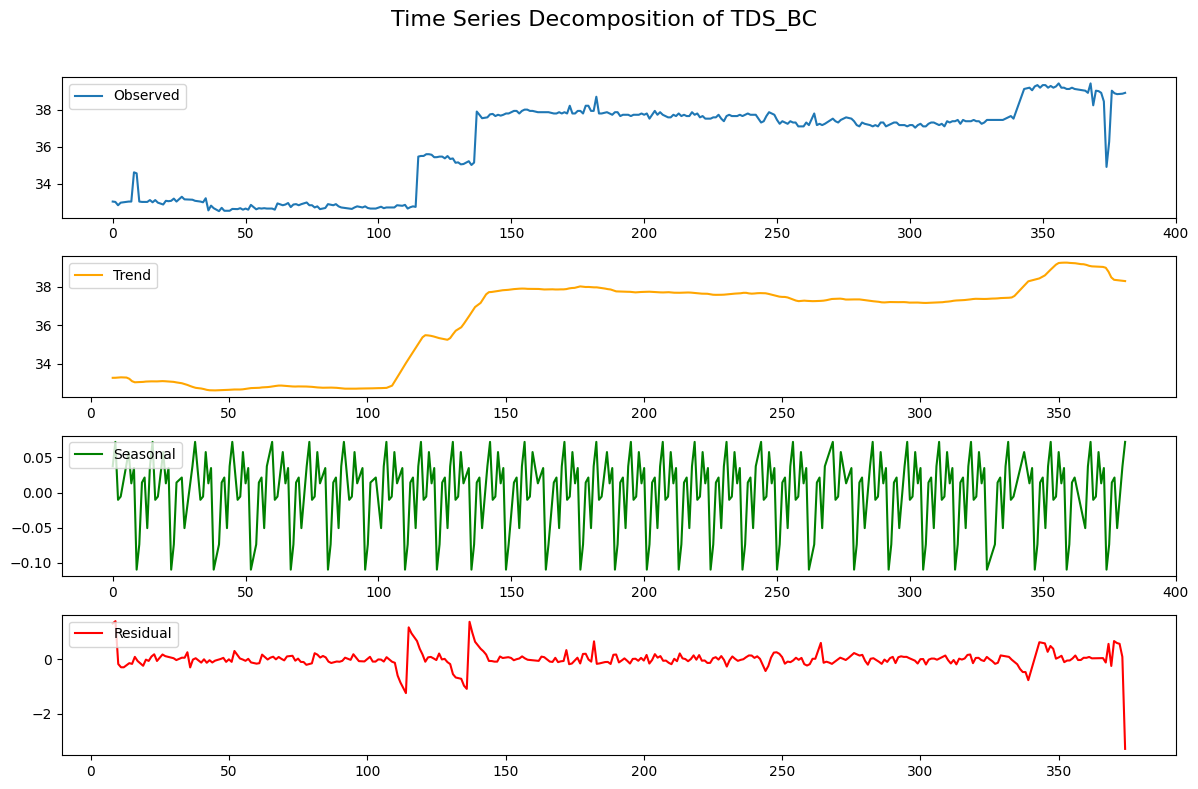

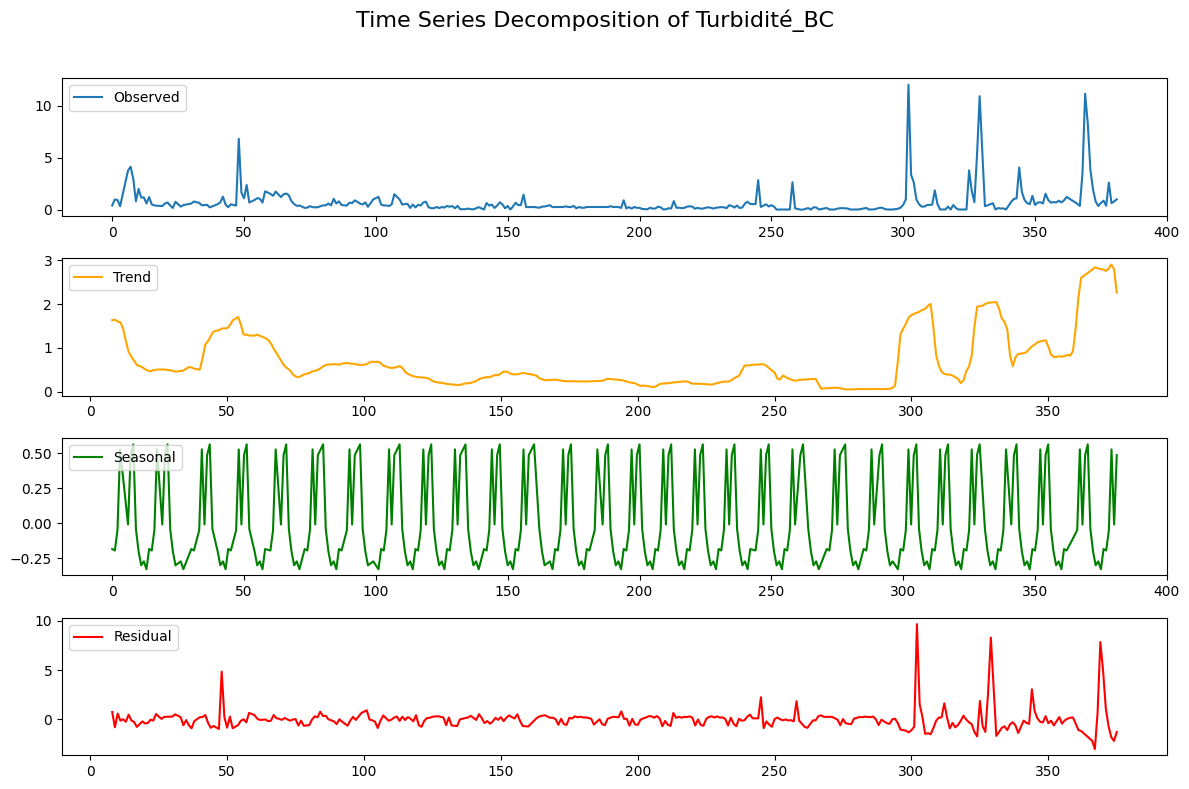

In [10]:
# time series decomposition for each BC variable

for col in BC_data.columns[1:]:
    decomp = seasonal_decompose(BC_data[col].dropna(), model='additive', period=12)
    plt.figure(figsize=(12, 8))
    plt.suptitle(f'Time Series Decomposition of {col}', fontsize=16)
    plt.subplot(411)
    plt.plot(decomp.observed, label='Observed')
    plt.legend(loc='upper left')
    plt.subplot(412)
    plt.plot(decomp.trend, label='Trend', color='orange')
    plt.legend(loc='upper left')
    plt.subplot(413)
    plt.plot(decomp.seasonal, label='Seasonal', color='green')
    plt.legend(loc='upper left')
    plt.subplot(414)
    plt.plot(decomp.resid, label='Residual', color='red')
    plt.legend(loc='upper left')
    plt.tight_layout(rect=[0, 0, 1, 0.96])